# **Исследование методов эффективного применения адаптеров (LoRA)  для дообучения моделей в условиях ограниченных вычислительных ресурсов**

**Содержание работы:**
1. EDA (самостоятельно собранные данные (fontanka.ru и dp.ru)) - **RU**
2. Эксперименты с моделью **Qwen3-0.6B**:
- Эксперимент 1 - Baseline
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 2 - LoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 3 - QLoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки
- Эксперимент 4 - OrthoGeoLoRA
  - эксперимент проводится для датасета в объеме 8212 / 8000 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

# Настройка окружения и инициализация

In [1]:
!pip install transformers accelerate peft datasets evaluate bitsandbytes


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%pip -q install "transformers>=4.43" "datasets>=2.18" "accelerate>=0.33" "trl>=0.9" "bitsandbytes>=0.45"

import os, random, math, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    DataCollatorForLanguageModeling
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available())

MODEL_NAME = "Qwen/Qwen3-0.6B"

DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print("device:", device, "| dtype:", DTYPE)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
True
device: cuda | dtype: torch.bfloat16


In [3]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import accuracy_score, f1_score
import evaluate

# **EDA (заголовки с fontanka.ru и dp.ru)**

- Загрузка датасета - самостоятельно собранные заголовки с сайтов fontanka.ru и dp.ru
- EDA (размеры, классы, длины, графики)

In [4]:
# Загрузка датасета
ds = pd.read_csv('result.csv')

In [5]:
ds

,text,label
0,Петербург и Ленобласть в этом году отремонтиру...,auto
1,Прямое железнодорожное сообщение свяжет Мурман...,auto
2,Поддать газу. Hyundai в следующем году начнет ...,auto
3,"Двое водителей не поделили проспект Науки, и о...",auto
4,Литий-ионные батареи для российских электромоб...,auto
...,...,...
41055,КХЛ отменила регулярный чемпионат,sport
41056,В Петербурге появился третий профессиональный ...,sport
41057,Российский гонщик отметил победу в Португалии ...,sport
41058,Защитник «Зенита» против лимита: меньше иностр...,sport


Список колонок:
['text', 'label']

Размер датасета:
(41060, 2)

Три случайных примера:

Пример 7296:
Text: Дзюба — о будущем: «Акрон» в приоритете, но всё решится позже
Label: sport

Пример 1639:
Text: За октябрь инспекторы ГАИ выявили в Петербурге и Ленобласти более 800 случаев вождения в нетрезвом состоянии, сообщили в пресс-службе региональной Госавтоинспекции.
Label: auto

Пример 18024:
Text: В январе-сентябре 2019 года операционная прибыль филиала Альфа-Банка в Петербурге составила 10,9 млрд рублей, что на 37% больше показателя за аналогичный период прошлого года. Об этом сообщает пресс-служба кредитной организации.
Label: finances

Train size: 32848
Test size:  8212

Columns: ['text', 'label']

Class distribution (train):
label
realty      8212
sport       8212
finances    8212
auto        8212
Name: count, dtype: int64

Class distribution (test):
label
realty      2053
auto        2053
finances    2053
sport       2053
Name: count, dtype: int64

Average text length (train): 107.

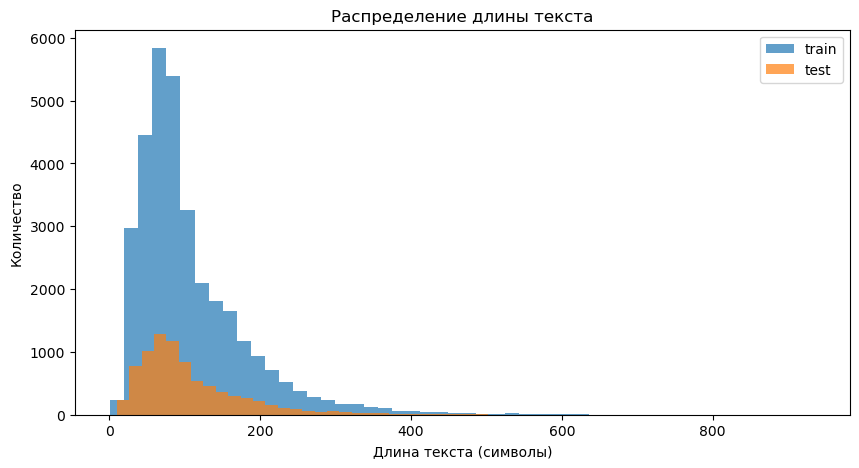

In [6]:
# Делим данные
X = ds['text']
y = ds['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Объединяем обратно в DataFrame
train = pd.DataFrame({
    'text': X_train,
    'label': y_train
}).reset_index(drop=True)

test = pd.DataFrame({
    'text': X_test,
    'label': y_test
}).reset_index(drop=True)

# Основная информация
print("Список колонок:")
print(ds.columns.tolist())

print("\nРазмер датасета:")
print(ds.shape)

# Случайные примеры
print("\nТри случайных примера:")

random_indices = random.sample(range(len(train)), 3)

for idx in random_indices:
    example = train.iloc[idx]
    print(f"\nПример {idx}:")
    print(f"Text: {example['text']}")
    print(f"Label: {example['label']}")

# Статистика
df_train = train.copy()
df_test = test.copy()

print(f"\nTrain size: {len(df_train)}")
print(f"Test size:  {len(df_test)}")

print("\nColumns:", df_train.columns.tolist())

# Распределение классов
print("\nClass distribution (train):")
print(df_train['label'].value_counts())

print("\nClass distribution (test):")
print(df_test['label'].value_counts())

# Длина текста
df_train['text_len'] = df_train['text'].apply(len)
df_test['text_len'] = df_test['text'].apply(len)

print(f"\nAverage text length (train): {df_train['text_len'].mean():.1f} characters")
print(f"Average text length (test):  {df_test['text_len'].mean():.1f} characters")

print(f"Text length range (train): {df_train['text_len'].min()} - {df_train['text_len'].max()}")
print(f"Text length range (test):  {df_test['text_len'].min()} - {df_test['text_len'].max()}")

plt.figure(figsize=(10,5))
plt.hist(df_train['text_len'], bins=50, alpha=0.7, label='train')
plt.hist(df_test['text_len'], bins=50, alpha=0.7, label='test')
plt.xlabel("Длина текста (символы)")
plt.ylabel("Количество")
plt.title("Распределение длины текста")
plt.legend()
plt.show()

In [7]:
# Преобразование label в числа
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['label'] = le.fit_transform(train['label'])
test['label'] = le.transform(test['label'])

num_labels = len(le.classes_)

In [8]:
# части датасета
# 8000 образцов в каждом классе обучающей выборки
train_8000 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=8000, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_8000['label'].value_counts())
print("Размер:", train_8000.shape)

# 3000 образцов в каждом классе обучающей выборки
train_3000 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=3000, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_3000['label'].value_counts())
print("Размер:", train_3000.shape)

# 1500 образцов в каждом классе обучающей выборки
train_1500 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=1500, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_1500['label'].value_counts())
print("Размер:", train_1500.shape)

# 300 образцов в каждом классе обучающей выборки
train_300 = (
    train.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(n=300, random_state=42))
      .reset_index(drop=True)
)

# Проверка
print(train_300['label'].value_counts())
print("Размер:", train_300.shape)

label
0    8000
1    8000
2    8000
3    8000
Name: count, dtype: int64
Размер: (32000, 2)
label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64
Размер: (12000, 2)
label
0    1500
1    1500
2    1500
3    1500
Name: count, dtype: int64
Размер: (6000, 2)
label
0    300
1    300
2    300
3    300
Name: count, dtype: int64
Размер: (1200, 2)


/tmp/ipykernel_5735/522953867.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=8000, random_state=42))
/tmp/ipykernel_5735/522953867.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=3000, random_state=42))
/tmp/ipykernel_5735/522953867.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a futu

# Подготовка токенизатора

In [9]:
#Подготовка токенизатора
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Добавляем pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [10]:
def prepare_dataset(train=train, test=test, sample_frac=1.0, seed=42):
    """
    Подготовка датасета:
    - pandas в HF Dataset
    - сэмплирование
    - токенизация
    - label в labels
    """

    # 1. pandas в Dataset
    train_ds = Dataset.from_pandas(train)
    test_ds = Dataset.from_pandas(test)

    # 2. Сэмплирование
    train_ds = train_ds.shuffle(seed=seed).select(
        range(int(sample_frac * len(train_ds)))
    )

    # 3. Токенизация
    train_tok = train_ds.map(tokenize, batched=True)
    test_tok = test_ds.map(tokenize, batched=True)

    # 4. Удаление лишнего
    train_tok = train_tok.remove_columns(["text"])
    test_tok = test_tok.remove_columns(["text"])

    # 5. label → labels
    train_tok = train_tok.rename_column("label", "labels")
    test_tok = test_tok.rename_column("label", "labels")

    # 6. Формат для PyTorch
    train_tok.set_format("torch")
    test_tok.set_format("torch")

    return train_tok, test_tok

# **Эксперимент 1 - Baseline**

**План эксперимента 1 - Baseline**:

- Определение функций для эксперимента
- Определение объема выборки
- Baseline-эксперимент:
  - загружается базовая модель Qwen3-0.6B
  - замораживаются все параметры, кроме классификационной головы
  - Trainer обучает 1 эпоху
  - собираются baseline-метрики

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- добавление baseline
- сохранение в lora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 1

In [11]:
def load_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        torch_dtype=torch.float16,
        device_map="auto",
        ignore_mismatched_sizes=True
    )

In [12]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [13]:
# Заморозка модели (baseline)
def freeze_all_but_head(model):
    for name, param in model.named_parameters():
        if "classifier" not in name and "score" not in name:
            param.requires_grad = False
    return model


# Подсчёт trainable параметров
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Обучение + инференс
def train_and_predict(model, train_tok, test_tok, tokenizer):
    args = TrainingArguments(
        output_dir="./outputs/baseline",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
        compute_metrics=compute_metrics,
    )

    start = time.time()
    trainer.train()
    mid = time.time()

    pred_test = trainer.predict(test_tok)
    end = time.time()

    pred_train = trainer.predict(train_tok)

    return pred_train, pred_test, mid - start, end - mid


# Подсчёт метрик
def compute_full_metrics(pred):
    logits = pred.predictions
    labels = pred.label_ids
    preds = np.argmax(logits, axis=-1)

    loss = F.cross_entropy(
        torch.tensor(logits),
        torch.tensor(labels)
    ).item()

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "loss": loss
    }


# GPU метрики
def get_gpu_metrics():
    if torch.cuda.is_available():
        return {
            "gpu_memory_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3,
            "gpu_memory_reserved_gb": torch.cuda.max_memory_reserved() / 1024**3,
        }
    return {
        "gpu_memory_allocated_gb": 0,
        "gpu_memory_reserved_gb": 0,
    }


# функция baseline
def run_baseline(train_tok, test_tok, tokenizer):
    print("\nЗапуск Baseline (только classification head)")

    model = load_base_model()
    model = freeze_all_but_head(model)

    print(f"Trainable parameters: {count_trainable_params(model):,}")

    pred_train, pred_test, time_train, time_eval = train_and_predict(
        model, train_tok, test_tok, tokenizer
    )

    train_metrics = compute_full_metrics(pred_train)
    test_metrics = compute_full_metrics(pred_test)
    gpu_metrics = get_gpu_metrics()

    return {
        "train_accuracy": train_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "train_loss": train_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1": test_metrics["f1"],
        "test_loss": test_metrics["loss"],
        "time_sec_train": time_train,
        "time_sec_eval": time_eval,
        **gpu_metrics
    }

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.589316,0.560547,0.798831,0.798213


{'train_accuracy': 0.7931989771066732,
 'train_f1': 0.7926897806581239,
 'train_loss': 0.568359375,
 'test_accuracy': 0.7988309790550414,
 'test_f1': 0.7982128692362062,
 'test_loss': 0.5615234375,
 'time_sec_train': 357.6903395652771,
 'time_sec_eval': 67.80096769332886,
 'gpu_memory_allocated_gb': 1.2894277572631836,
 'gpu_memory_reserved_gb': 1.30078125}

In [ ]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_DP_baseline_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_100pct.csv")


Результаты сохранены в qw3_PD_baseline_100pct.csv


### **8000 образцов в каждом классе обучающей выборки**

In [15]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [16]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.532952,0.560059,0.800049,0.799432


{'train_accuracy': 0.79375,
 'train_f1': 0.7932089741638452,
 'train_loss': 0.56787109375,
 'test_accuracy': 0.80004870920604,
 'test_f1': 0.7994324384244417,
 'test_loss': 0.56005859375,
 'time_sec_train': 349.5893189907074,
 'time_sec_eval': 67.90476512908936,
 'gpu_memory_allocated_gb': 1.289412498474121,
 'gpu_memory_reserved_gb': 1.30078125}

In [17]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_DP_baseline_8000pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_8000pct.csv")


Результаты сохранены в qw3_PD_baseline_8000pct.csv


### **3000 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [20]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.775491,0.691895,0.742694,0.741712


{'train_accuracy': 0.7421666666666666,
 'train_f1': 0.7415430229805993,
 'train_loss': 0.68798828125,
 'test_accuracy': 0.7426936190940088,
 'test_f1': 0.7417116982349345,
 'test_loss': 0.6923828125,
 'time_sec_train': 174.57220363616943,
 'time_sec_eval': 67.92464470863342,
 'gpu_memory_allocated_gb': 2.399329662322998,
 'gpu_memory_reserved_gb': 2.41015625}

In [21]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_PD_baseline_3000pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_3000pct.csv")


Результаты сохранены в qw3_PD_baseline_3000pct.csv


### **1500 образцов в каждом классе обучающей выборки**

In [32]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [33]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.868027,0.864258,0.657087,0.655718


{'train_accuracy': 0.6623333333333333,
 'train_f1': 0.6617801676918068,
 'train_loss': 0.85888671875,
 'test_accuracy': 0.6570871894788115,
 'test_f1': 0.6557176839453469,
 'test_loss': 0.865234375,
 'time_sec_train': 119.36542654037476,
 'time_sec_eval': 67.11345529556274,
 'gpu_memory_allocated_gb': 3.8291664123535156,
 'gpu_memory_reserved_gb': 3.8828125}

In [34]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_PD_baseline_1500.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_1500.csv")


Результаты сохранены в qw3_PD_baseline_1200.csv


### **300 образцов в каждом классе обучающей выборки**

In [41]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [42]:
# Baseline: только classification head
print("\nЗапуск Baseline (только classification head)")
base_model = load_base_model()
# Замораживаем все слои кроме классификационной головы
for name, param in base_model.named_parameters():
    if "classifier" not in name and "score" not in name:
        param.requires_grad = False

print(f"Trainable parameters in baseline: {sum(p.numel() for p in base_model.parameters() if p.requires_grad):,}")


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters in baseline: 4,096


In [43]:
baseline_metrics = run_baseline(train_tok, test_tok, tokenizer)
baseline_metrics


Запуск Baseline (только classification head)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 4,096


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.285435,1.259766,0.468095,0.456688


{'train_accuracy': 0.46166666666666667,
 'train_f1': 0.45020690190166845,
 'train_loss': 1.2587890625,
 'test_accuracy': 0.4680954700438383,
 'test_f1': 0.4566875865080803,
 'test_loss': 1.26171875,
 'time_sec_train': 78.61966753005981,
 'time_sec_eval': 67.72012853622437,
 'gpu_memory_allocated_gb': 4.039239406585693,
 'gpu_memory_reserved_gb': 4.119140625}

In [44]:
# Создаем DataFrame из baseline_metrics (одна строка)
df_baseline_metrics = pd.DataFrame([baseline_metrics])

# Сохраняем результаты
df_baseline_metrics.to_csv("qw3_PD_baseline_300.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_baseline_300.csv")


Результаты сохранены в qw3_PD_baseline_300.csv


# **Эксперимент 2 - LoRA**

**План эксперимента 2 - LoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в lora_results.csv
- вывод сводной таблицы


Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 2

In [18]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = create_lora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [ ]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.235524,0.398438,0.904286,0.904119


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.298094,0.326660,0.917925,0.917748


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1199.9614126682281, 'time_sec_eval': 97.51859641075134, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.9392352654651729, 'train_f1': 0.9391731811794216, 'train_loss': 0.232666015625, 'test_accuracy': 0.9179249878226985, 'test_f1': 0.9177476695744007, 'test_loss': 0.32666015625}


**Агрегация результатов**

In [ ]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_PD_lora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_lora_results_100pct.csv")
df_results


Результаты сохранены в qw3_PD_lora_results_100pct.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,979.729035,79.855940,4,q_proj-v_proj,3.047973,3.115234,577536,0.912171,0.912018,0.356689,0.904286,0.904119,0.398438
1,1065.443275,86.512799,4,q_proj-k_proj-v_proj,3.190670,3.261719,806912,0.914302,0.914258,0.347656,0.904530,0.904445,0.386719
2,1167.488127,91.810446,4,q_proj-k_proj-v_proj-o_proj,3.468406,3.500000,1150976,0.917864,0.917792,0.326416,0.909523,0.909360,0.370117
3,978.114989,79.254240,8,q_proj-v_proj,3.055236,3.123047,1150976,0.916403,0.916282,0.330322,0.907453,0.907257,0.379639
4,1061.259833,85.794758,8,q_proj-k_proj-v_proj,3.200923,3.271484,1609728,0.921091,0.921053,0.319824,0.909766,0.909612,0.376221
5,1165.038853,91.612385,8,q_proj-k_proj-v_proj-o_proj,3.482933,3.515625,2297856,0.923039,0.922990,0.297119,0.911349,0.911201,0.358398
6,978.807645,80.050011,16,q_proj-v_proj,3.069763,3.136719,2297856,0.922948,0.922872,0.302979,0.910862,0.910665,0.361816
7,1059.442078,85.718138,16,q_proj-k_proj-v_proj,3.221431,3.292969,3215360,0.926997,0.926961,0.291748,0.912323,0.912174,0.363037
8,1152.219990,91.587477,16,q_proj-k_proj-v_proj-o_proj,3.511985,3.544922,4591616,0.930802,0.930711,0.263916,0.915490,0.915258,0.345703
9,996.624528,81.713864,32,q_proj-v_proj,3.098815,3.166016,4591616,0.929006,0.928942,0.265381,0.913298,0.913118,0.340332


### **8000 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [20]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.222607,0.389404,0.905261,0.905188


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.183096,0.327881,0.919873,0.919859


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1192.246571302414, 'time_sec_eval': 98.58285999298096, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.5700907707214355, 'gpu_memory_reserved_gb': 3.603515625, 'trainable_parameters': 9179136, 'train_accuracy': 0.939, 'train_f1': 0.939065719199896, 'train_loss': 0.2340087890625, 'test_accuracy': 0.9198733560642961, 'test_f1': 0.9198593032352339, 'test_loss': 0.32763671875}


**Агрегация результатов**

In [21]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_PD_lora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_lora_results_8000.csv")
df_results


Результаты сохранены в qw3_PD_lora_results_8000.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,950.820659,79.003632,4,q_proj-v_proj,3.047973,3.115234,577536,0.911906,0.911944,0.355713,0.905261,0.905188,0.389648
1,1031.407963,85.119144,4,q_proj-k_proj-v_proj,3.190670,3.261719,806912,0.913250,0.913270,0.348145,0.905017,0.905018,0.380371
2,1124.934654,90.749981,4,q_proj-k_proj-v_proj-o_proj,3.468406,3.500000,1150976,0.916375,0.916424,0.333008,0.907940,0.907923,0.374023
3,946.947112,78.649946,8,q_proj-v_proj,3.055236,3.123047,1150976,0.909937,0.909896,0.381836,0.904165,0.904128,0.422607
4,1033.824957,84.869240,8,q_proj-k_proj-v_proj,3.200923,3.271484,1609728,0.920406,0.920469,0.317383,0.910619,0.910651,0.365723
5,1126.217637,90.559349,8,q_proj-k_proj-v_proj-o_proj,3.482933,3.515625,2297856,0.923188,0.923265,0.304199,0.911349,0.911367,0.368164
6,948.160956,79.537037,16,q_proj-v_proj,3.069763,3.136719,2297856,0.915906,0.915933,0.353760,0.909036,0.908984,0.403076
7,1032.044127,85.729288,16,q_proj-k_proj-v_proj,3.221431,3.292969,3215360,0.927813,0.927846,0.291016,0.915002,0.915005,0.356445
8,1128.659008,91.679914,16,q_proj-k_proj-v_proj-o_proj,3.511985,3.544922,4591616,0.928500,0.928536,0.274658,0.917560,0.917533,0.338867
9,976.027714,81.927709,32,q_proj-v_proj,3.098815,3.166016,4591616,0.926531,0.926564,0.284180,0.914028,0.913982,0.351562


### **3000 образцов в каждом классе обучающей выборки**

In [23]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [24]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.529539,0.453613,0.891744,0.891655


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.476657,0.392334,0.902825,0.902791


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 500.91619348526, 'time_sec_eval': 97.23798155784607, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.680342674255371, 'gpu_memory_reserved_gb': 4.712890625, 'trainable_parameters': 9179136, 'train_accuracy': 0.9300833333333334, 'train_f1': 0.9301316013651115, 'train_loss': 0.25732421875, 'test_accuracy': 0.9028251339503166, 'test_f1': 0.9027906250759766, 'test_loss': 0.392578125}


**Агрегация результатов**

In [25]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_PD_lora_results_3000.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_lora_results_3000.csv")
df_results


Результаты сохранены в qw3_PD_lora_results_3000.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,406.918833,79.581019,4,q_proj-v_proj,4.158225,4.224609,577536,0.902083,0.901990,0.385742,0.891744,0.891655,0.453857
1,440.906809,85.252326,4,q_proj-k_proj-v_proj,4.300921,4.371094,806912,0.902667,0.902641,0.381592,0.892596,0.892472,0.450439
2,478.269305,90.302577,4,q_proj-k_proj-v_proj-o_proj,4.578658,4.609375,1150976,0.907167,0.907235,0.364746,0.895762,0.895839,0.456055
3,404.646988,78.687302,8,q_proj-v_proj,4.165488,4.251953,1150976,0.904833,0.904785,0.362549,0.895275,0.895265,0.430420
4,439.183723,84.512236,8,q_proj-k_proj-v_proj,4.311175,4.380859,1609728,0.893750,0.893776,0.484619,0.883220,0.883272,0.559082
5,477.220932,89.961860,8,q_proj-k_proj-v_proj-o_proj,4.593184,4.625000,2297856,0.915083,0.915135,0.335693,0.897711,0.897658,0.435059
6,405.854080,79.291375,16,q_proj-v_proj,4.180015,4.265625,2297856,0.913583,0.913577,0.328613,0.898076,0.898066,0.418213
7,440.004434,85.226490,16,q_proj-k_proj-v_proj,4.331683,4.402344,3215360,0.917000,0.917029,0.325928,0.898685,0.898626,0.434814
8,479.027310,91.187443,16,q_proj-k_proj-v_proj-o_proj,4.622237,4.654297,4591616,0.921250,0.921337,0.291016,0.899659,0.899634,0.401611
9,415.987995,81.800102,32,q_proj-v_proj,4.209067,4.294922,4591616,0.922083,0.922071,0.297119,0.900146,0.900124,0.405029


### **1500 образцов в каждом классе обучающей выборки**

In [35]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [36]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.413419,0.501602,0.854238,0.854199


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.476278,0.495105,0.888699,0.888472


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 342.4584336280823, 'time_sec_eval': 115.07543563842773, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.8286781311035156, 'gpu_memory_reserved_gb': 3.876953125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9308333333333333, 'train_f1': 0.9307334920505334, 'train_loss': 0.2795720100402832, 'test_accuracy': 0.8886994641987336, 'test_f1': 0.8884722185743894, 'test_loss': 0.4950549602508545}


**Агрегация результатов**

In [37]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("qw3_PD_lora_results_1200.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_lora_results_1200.csv")
df_results


Результаты сохранены в qw3_PD_lora_results_1200.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,315.559604,108.685567,4,q_proj-v_proj,3.460201,3.484375,577536,0.871500,0.871559,0.434970,0.854238,0.854199,0.501547
1,331.103575,111.759858,4,q_proj-k_proj-v_proj,3.544510,3.583984,806912,0.883333,0.883254,0.421668,0.863249,0.863128,0.515898
2,342.801513,115.687136,4,q_proj-k_proj-v_proj-o_proj,3.718182,3.746094,1150976,0.900000,0.899832,0.396916,0.875304,0.875053,0.512337
3,312.725709,107.004466,8,q_proj-v_proj,3.468578,3.523438,1150976,0.891167,0.891017,0.401439,0.867146,0.866981,0.516389
4,327.629184,111.635470,8,q_proj-k_proj-v_proj,3.557060,3.595703,1609728,0.898833,0.898804,0.391682,0.870312,0.870208,0.529705
5,341.354929,115.362010,8,q_proj-k_proj-v_proj-o_proj,3.733479,3.761719,2297856,0.910500,0.910344,0.359222,0.882367,0.882083,0.498908
6,314.108746,108.121173,16,q_proj-v_proj,3.483379,3.519531,2297856,0.905667,0.905567,0.375555,0.874208,0.873995,0.522344
7,327.204222,111.613619,16,q_proj-k_proj-v_proj,3.581184,3.617188,3215360,0.911833,0.911791,0.338659,0.879079,0.878895,0.494960
8,340.150666,115.027841,16,q_proj-k_proj-v_proj-o_proj,3.764072,3.792969,4591616,0.921667,0.921602,0.313579,0.885168,0.884869,0.487660
9,313.675361,106.766824,32,q_proj-v_proj,3.517376,3.550781,4591616,0.917667,0.917665,0.330552,0.881393,0.881357,0.517351


### **300 образцов в каждом классе обучающей выборки**

In [45]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [46]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск LoRA r={r}, modules={m} ===")
        try:
            metrics = run_experiment(rank=r, target_modules=m)
            print(metrics)
            results.append(metrics)
        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск LoRA r=4, modules=['q_proj', 'v_proj'] ===

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.285336,1.349668,0.394423,0.376381


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.546441,0.506255,0.836459,0.836801


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 164.59235501289368, 'time_sec_eval': 117.47377252578735, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.960658073425293, 'gpu_memory_reserved_gb': 5.0078125, 'trainable_parameters': 9179136, 'train_accuracy': 0.8933333333333333, 'train_f1': 0.8933525004791788, 'train_loss': 0.29912468791007996, 'test_accuracy': 0.8364588407208963, 'test_f1': 0.8368014253526894, 'test_loss': 0.5062002539634705}


**Агрегация результатов**

In [47]:
# Создаем DataFrame со всеми результатами
df_results = pd.DataFrame(results)

# Сохраняем результаты
df_results.to_csv("lora_PD_results_300.csv", index=False)
print("\nРезультаты сохранены в lora_PD_results_300.csv")
df_results


Результаты сохранены в lora_PD_results_300.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,150.953363,108.462758,4,q_proj-v_proj,4.574847,4.607422,577536,0.428333,0.410150,1.260705,0.394423,0.376381,1.349693
1,158.217080,113.385944,4,q_proj-k_proj-v_proj,4.678443,4.714844,806912,0.444167,0.432439,1.253664,0.416464,0.404440,1.311217
2,164.362568,116.416188,4,q_proj-k_proj-v_proj-o_proj,4.832339,4.857422,1150976,0.592500,0.590716,0.951396,0.547491,0.540227,1.049450
3,152.165389,109.547555,8,q_proj-v_proj,4.590793,4.654297,1150976,0.610000,0.601554,0.932851,0.574525,0.567854,1.017888
4,157.146706,112.421426,8,q_proj-k_proj-v_proj,4.676101,4.707031,1609728,0.529167,0.520423,1.099823,0.478324,0.467119,1.183087
5,164.359998,117.400388,8,q_proj-k_proj-v_proj-o_proj,4.861552,4.912109,2297856,0.708333,0.709167,0.720244,0.652947,0.652210,0.843545
6,151.284590,108.861703,16,q_proj-v_proj,4.604861,4.630859,2297856,0.801667,0.800152,0.533550,0.749878,0.749366,0.655676
7,157.492688,113.032624,16,q_proj-k_proj-v_proj,4.709258,4.767578,3215360,0.670000,0.667717,0.830482,0.601437,0.595914,0.943156
8,162.525820,115.748660,16,q_proj-k_proj-v_proj-o_proj,4.883601,4.923828,4591616,0.830000,0.830839,0.443877,0.776181,0.776858,0.586095
9,152.015829,109.300735,32,q_proj-v_proj,4.642520,4.703125,4591616,0.887500,0.888101,0.326495,0.825865,0.827020,0.523395


# Эксперимент 3 - QLoRA

**План эксперимента 3 - QLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]
  - Методы квантизации
    - NF4
    - FP4

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в qlora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки на 8212 / 3000 / 1500 / 300 образцов в каждом классе обучающей выборки

### Функции для эксперимента 3

In [14]:
# Функция создания модели с QLoRA

def create_qlora_model(rank, target_modules, quant_type="nf4"):
    """
    Создает модель с 4-битным квантованием и LoRA адаптерами

    Args:
        rank: ранг LoRA
        target_modules: список модулей для адаптации
        quant_type: тип квантования ("nf4" или "fp4")
    """

    # Конфигурация квантования
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type=quant_type,  # "nf4" или "fp4"
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )

    # Загружаем базовую модель с квантованием
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        quantization_config=bnb_config,
        device_map="auto",
        torch_dtype=torch.bfloat16,
        trust_remote_code=True
    )

    # Конфигурация LoRA
    lora_config = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        target_modules=target_modules,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS
    )

    # Оборачиваем модель в LoRA
    model = get_peft_model(base_model, lora_config)

    return model

In [15]:
# Функция для вычисления метрик

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

In [16]:
# Функция для запуска эксперимента

def run_experiment(rank, target_modules, quant_type="nf4", output_dir="./qlora_outputs"):
    """
    Запускает один эксперимент QLoRA

    Args:
        rank: ранг LoRA
        target_modules: список модулей
        quant_type: тип квантования ("nf4" или "fp4")
        output_dir: директория для сохранения

    Returns:
        dict: метрики эксперимента
    """

    # Создаем уникальное имя для эксперимента
    modules_str = "-".join(target_modules)
    exp_name = f"qlora_{quant_type}_r{rank}_{modules_str}"

    print(f"\n{'='*60}")
    print(f"Запуск: {exp_name}")
    print(f"{'='*60}")

    metrics = {}

    # Создаем модель
    try:
        model = create_qlora_model(rank, target_modules, quant_type)
        trainable_params = model.num_parameters(only_trainable=True)
        print(f"Trainable parameters: {trainable_params:,}")
    except Exception as e:
        print(f"Ошибка при создании модели: {e}")
        return None

    # Аргументы для тренировки
    training_args = TrainingArguments(
        output_dir=f"{output_dir}/{exp_name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=False,
        bf16=True,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{exp_name}/logs"
    )

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [ ]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.337461,0.424699,0.900755,0.900555


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 3,215,360


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_PD_qlora_results_100pct.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_100pct.csv")


Результаты сохранены в qw3_PD_qlora_results_100pct_nf4_1.csv


In [20]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: fp4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_fp4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.327421,0.382298,0.907818,0.907705


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1367.232317686081, 'time_sec_eval': 115.71950817108154, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.71915864944458, 'gpu_memory_reserved_gb': 2.7578125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9314722357525572, 'train_f1': 0.931439652111942, 'train_loss': 0.269919753074646, 'test_accuracy': 0.9078178275694107, 'test_f1': 0.907704656773155, 'test_loss': 0.3822867274284363}


In [21]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_PD_qlora_results_100pct_fp4.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_100pct_fp4.csv")


Результаты сохранены в qw3_PD_qlora_results_100pct_fp4.csv


In [23]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'k_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-k_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 806,912


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.384592,0.420638,0.901120,0.900921


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.304408,0.341051,0.914272,0.914146


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1366.326481103897, 'time_sec_eval': 115.82947134971619, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.71427583694458, 'gpu_memory_reserved_gb': 2.7578125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9365867023867511, 'train_f1': 0.9365783189564915, 'train_loss': 0.23870161175727844, 'test_accuracy': 0.9142717973697029, 'test_f1': 0.9141460534950605, 'test_loss': 0.34101736545562744}


In [24]:
# Создаем DataFrame
df_qlora_results_100pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_100pct.to_csv("qw3_PD_qlora_results_100pct_nf4_2.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_100pct_nf4_2.csv")


Результаты сохранены в qw3_PD_qlora_results_100pct_nf4_2.csv


### **8000 образцов в каждом классе обучающей выборки**

In [17]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [18]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.228645,0.353888,0.911349,0.911423


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 1332.5352709293365, 'time_sec_eval': 116.1029736995697, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 2.71989107131958, 'gpu_memory_reserved_gb': 2.7578125, 'trainable_parameters': 9179136, 'train_accuracy': 0.93640625, 'train_f1': 0.9364933039840384, 'train_loss': 0.24278832972049713, 'test_accuracy': 0.9113492450073064, 'test_f1': 0.9114230628704373, 'test_loss': 0.353874534368515}


In [19]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw3_PD_qlora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_8000.csv")


Результаты сохранены в qw3_PD_qlora_results_8000.csv


### **3000 образцов в каждом классе обучающей выборки**

In [29]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [30]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.546568,0.490180,0.882002,0.882064


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.514069,0.424588,0.898198,0.898214


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 578.1674149036407, 'time_sec_eval': 117.76533961296082, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.8291664123535156, 'gpu_memory_reserved_gb': 3.8828125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9279166666666666, 'train_f1': 0.9279225367643702, 'train_loss': 0.2602178752422333, 'test_accuracy': 0.8981977593765221, 'test_f1': 0.898214403599948, 'test_loss': 0.42454543709754944}


In [31]:
# Создаем DataFrame
df_qlora_results_50pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_50pct.to_csv("qw3_PD_qlora_results_3000.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_3000.csv")


Результаты сохранены в qw3_PD_qlora_results_3000.csv


### **1500 образцов в каждом классе обучающей выборки**

In [38]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [39]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.373127,0.484649,0.848636,0.848357


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.544660,0.509092,0.884803,0.884712


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 347.19279503822327, 'time_sec_eval': 117.22524356842041, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.8325843811035156, 'gpu_memory_reserved_gb': 3.876953125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9215, 'train_f1': 0.9214308396633442, 'train_loss': 0.3103664815425873, 'test_accuracy': 0.8848027277155383, 'test_f1': 0.8847122366265608, 'test_loss': 0.5090349912643433}


In [40]:
# Создаем DataFrame
df_qlora_results_10pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_10pct.to_csv("qw3_PD_qlora_results_1500.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_1500.csv")


Результаты сохранены в qw3_PD_qlora_results_1200.csv


### **300 образцов в каждом классе обучающей выборки**

In [48]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [51]:
# Параметры экспериментов
ranks = [4, 8, 16, 32]
target_modules_sets = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]
quant_types = ["nf4", "fp4"]  # Тестируем оба типа квантования ["nf4", "fp4"]

# Список для сбора результатов
qlora_results = []

# Запускаем все комбинации
for quant_type in quant_types:
    for modules in target_modules_sets:
        for rank in ranks:
            print(f"\n>>> Тестируем: {quant_type}, rank={rank}, modules={modules}")

            metrics = run_experiment(
                rank=rank,
                target_modules=modules,
                quant_type=quant_type
            )
            print(metrics)

            if metrics:
                qlora_results.append(metrics)

            # Небольшая пауза между экспериментами
            time.sleep(2)


>>> Тестируем: nf4, rank=4, modules=['q_proj', 'v_proj']

Запуск: qlora_nf4_r4_q_proj-v_proj


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,536


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.280295,1.264447,0.435826,0.426583


...

Trainable parameters: 9,179,136


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.559976,0.567401,0.837920,0.838955


Getting predictions on test set...


Getting predictions on train set...


{'time_sec_train': 165.34027409553528, 'time_sec_eval': 117.7043342590332, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 4.962611198425293, 'gpu_memory_reserved_gb': 5.0078125, 'trainable_parameters': 9179136, 'train_accuracy': 0.9141666666666667, 'train_f1': 0.9142245521982894, 'train_loss': 0.30494195222854614, 'test_accuracy': 0.8379201169020944, 'test_f1': 0.8389545846346973, 'test_loss': 0.5673768520355225}


In [50]:
# Создаем DataFrame
df_qlora_results_5pct = pd.DataFrame(qlora_results)

# Сохраняем результаты
df_qlora_results_5pct.to_csv("qw3_PD_qlora_results_300.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_qlora_results_300.csv")


Результаты сохранены в qw3_PD_qlora_results_300.csv


# Эксперимент 4 - OrthoGeoLoRA

**План эксперимента 4 - OrthoGeoLoRA**:

- Определение функций для эксперимента
- Определение объема выборки
- LoRA эксперименты
  - Rank
    - 4
    - 8
    - 16
    - 32
  - Наборы модулей
    - ["q_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj"]
    - ["q_proj", "k_proj", "v_proj", "o_proj"]

Для каждого запуска:
- обучение
- оценка
- замеры скорости
- замеры GPU-памяти

Агрегация результатов:
- DataFrame df_results
- сохранение в oglora_results.csv
- вывод сводной таблицы

Повтор эксперимента для выборки 8212 / 8000 / 3000 / 1500 / 300 

### Функции для эксперимента 4

In [14]:
class OrthogonalizationLayer(nn.Module):
    def __init__(self, in_dim, rank, dtype):
        super().__init__()
        self.theta = nn.Parameter(torch.randn(in_dim, rank, dtype=torch.float32) * 0.01)

    def forward(self):
        q, r = torch.linalg.qr(self.theta, mode="reduced")
        sign = torch.sign(torch.diag(r))
        q = q * sign.unsqueeze(0)
        return q

In [15]:
class OrthoGeoLoRALayer(nn.Module):
    def __init__(self, base_lora_layer):
        super().__init__()

        self.base_layer = base_lora_layer.base_layer

        if isinstance(base_lora_layer.r, dict):
            self.rank = list(base_lora_layer.r.values())[0]
        else:
            self.rank = base_lora_layer.r

        if isinstance(base_lora_layer.scaling, dict):
            self.scaling = list(base_lora_layer.scaling.values())[0]
        else:
            self.scaling = base_lora_layer.scaling

        in_features = self.base_layer.in_features
        out_features = self.base_layer.out_features

        dtype = self.base_layer.weight.dtype

        self.A_orth = OrthogonalizationLayer(in_features, self.rank, dtype)
        self.B_orth = OrthogonalizationLayer(out_features, self.rank, dtype)

        self.log_singular = nn.Parameter(torch.zeros(self.rank, dtype=dtype))

    @property
    def singular(self):
        return F.softplus(self.log_singular) + 1e-6

    def forward(self, x):

        base = self.base_layer(x)

        A = self.A_orth().to(x.dtype)
        B = self.B_orth().to(x.dtype)
        S = self.singular.to(x.dtype)

        xA = torch.matmul(x, A)
        xS = xA * S.unsqueeze(0)
        update = torch.matmul(xS, B.T)

        return base + update * self.scaling

In [16]:
def convert_lora_to_orthogeolora(model):

    for name, module in list(model.named_modules()):

        if hasattr(module, "lora_A") and hasattr(module, "lora_B"):

            parent = model
            path = name.split(".")
            for p in path[:-1]:
                parent = getattr(parent, p)

            lora_layer = getattr(parent, path[-1])

            ortho_layer = OrthoGeoLoRALayer(lora_layer)

            setattr(parent, path[-1], ortho_layer)

    return model

In [17]:
def create_orthogeolora_model(rank, target_modules):

    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )

    model = get_peft_model(base, lora_cfg)

    model = convert_lora_to_orthogeolora(model)

    return model

In [18]:
def create_lora_model(rank, target_modules):
    base = load_base_model()

    lora_cfg = LoraConfig(
        r=rank,
        lora_alpha=rank * 2,
        lora_dropout=0.05,
        target_modules=target_modules,
        task_type=TaskType.SEQ_CLS
    )
    return get_peft_model(base, lora_cfg)

def create_training_args(rank, target_modules, output_dir="./outputs"):
    name = f"r{rank}_" + "-".join(target_modules)

    return TrainingArguments(
        output_dir=f"{output_dir}/{name}",
        num_train_epochs=1,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        fp16=False,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=4,
        logging_dir=f"{output_dir}/{name}/logs",
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }

def run_experiment_oglora(rank, target_modules, output_dir="./outputs"):

    metrics = {}

    # Создаем модель
    model = None
    trainer = None

    model = create_orthogeolora_model(rank, target_modules)
    print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

    # Создаем аргументы для тренировки
    args = create_training_args(rank, target_modules, output_dir)

    # Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # Trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Мониторинг GPU до тренировки
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start_time = time.time()

    # Тренировка
    trainer.train()

    end_time_train = time.time()

    print("Getting predictions on train set...")
    pred_train = trainer.predict(train_tok)

    print("Getting predictions on test set...")
    pred_test = trainer.predict(test_tok)

    end_time_eval = time.time()

    # Оценка
    logits_train = pred_train.predictions
    labels_train = pred_train.label_ids
    preds_train = np.argmax(logits_train, axis=-1)
    logits_tensor_train = torch.tensor(logits_train)
    labels_tensor_train = torch.tensor(labels_train)
    loss_train = F.cross_entropy(logits_tensor_train, labels_tensor_train).item()

    logits_test = pred_test.predictions
    labels_test = pred_test.label_ids
    preds_test = np.argmax(logits_test, axis=-1)
    logits_tensor_test = torch.tensor(logits_test)
    labels_tensor_test = torch.tensor(labels_test)
    loss_test = F.cross_entropy(logits_tensor_test, labels_tensor_test).item()

    # Сбор метрик GPU
    if torch.cuda.is_available():
        gpu_memory_allocated = torch.cuda.max_memory_allocated() / 1024**3  # в GB
        gpu_memory_reserved = torch.cuda.max_memory_reserved() / 1024**3    # в GB
    else:
        gpu_memory_allocated = 0
        gpu_memory_reserved = 0

    # Добавляем все метрики в результат
    metrics["time_sec_train"] = end_time_train - start_time
    metrics["time_sec_eval"] = end_time_eval - end_time_train
    metrics["rank"] = rank
    metrics["modules"] = "-".join(target_modules)
    metrics["gpu_memory_allocated_gb"] = gpu_memory_allocated
    metrics["gpu_memory_reserved_gb"] = gpu_memory_reserved
    metrics["trainable_parameters"] = model.num_parameters(only_trainable=True)

    metrics["train_accuracy"] = accuracy_score(labels_train, preds_train)
    metrics["train_f1"] = f1_score(labels_train, preds_train, average="weighted")
    metrics["train_loss"] = loss_train

    metrics["test_accuracy"] = accuracy_score(labels_test, preds_test)
    metrics["test_f1"] = f1_score(labels_test, preds_test, average="weighted")
    metrics["test_loss"] = loss_test

    # Очистка памяти
    del model
    del trainer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

### **8212 образцов в каждом классе обучающей выборки**

In [21]:
train_tok, test_tok = prepare_dataset(sample_frac=1.0)

Map:   0%|          | 0/32848 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [22]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.349196,0.401367,0.909523,0.909351


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.368652,0.399170,0.910497,0.910436


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 3046.789689064026, 'time_sec_eval': 2200.6767041683197, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.9305893813930833, 'train_f1': 0.9305896818401069, 'train_loss': 0.2978515625, 'test_accuracy': 0.9104968339016074, 'test_f1': 0.9104355157313441, 'test_loss': 0.39892578125}


In [23]:
# Создаем DataFrame
df_oglora_results_100pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_100pct.to_csv("oglora_PD_results_8212.csv", index=False)
print("\nРезультаты сохранены в oglora_PD_results_8212.csv")


Результаты сохранены в oglora_PD_results_8212.csv


### **8000 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(train=train_8000)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [20]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.377661,0.607910,0.902947,0.902931


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 2982.155990600586, 'time_sec_eval': 2189.812502861023, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.91321875, 'train_f1': 0.9132721308488657, 'train_loss': 0.49853515625, 'test_accuracy': 0.9029469069654165, 'test_f1': 0.9029312628419767, 'test_loss': 0.6083984375}


In [21]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw3_PD_oglora_results_8000.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_oglora_results_8000.csv")


Результаты сохранены в qw3_PD_oglora_results_8000.csv


### **3000 образцов в каждом классе обучающей выборки**

In [19]:
train_tok, test_tok = prepare_dataset(train=train_3000)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [25]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.502626,0.428955,0.898198,0.898290


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 3,216,704


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [26]:
# Создаем DataFrame
df_oglora_results_50pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_50pct.to_csv("qw3_PD_oglora_results_3000_1.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_oglora_results_3000.csv")


Результаты сохранены в qw3_PD_oglora_results_3000.csv


In [20]:
# LoRA эксперименты
ranks = [16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=16, modules=['q_proj', 'v_proj'] ===


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 2,298,752


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.463511,0.449219,0.897954,0.897899


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 1394.44318318367, 'time_sec_eval': 1101.2172837257385, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.92975, 'train_f1': 0.9297645985996457, 'train_loss': 0.28076171875, 'test_accuracy': 0.8979542133463224, 'test_f1': 0.8978985355680499, 'test_loss': 0.44921875}


In [21]:
# Создаем DataFrame
df_oglora_results = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results.to_csv("qw3_PD_oglora_results_3000_2.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_oglora_results_3000.csv")


Результаты сохранены в qw3_PD_oglora_results_3000.csv


### **1500 образцов в каждом классе обучающей выборки**

In [22]:
train_tok, test_tok = prepare_dataset(train=train_1500)

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [23]:
# LoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.534452,0.525879,0.883098,0.882781


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.343265,1.291992,0.874574,0.875039


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 923.3044812679291, 'time_sec_eval': 777.8882284164429, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.9011666666666667, 'train_f1': 0.9014248627398882, 'train_loss': 0.91015625, 'test_accuracy': 0.8745737944471506, 'test_f1': 0.875038767013132, 'test_loss': 1.291015625}


In [24]:
# Создаем DataFrame
df_oglora_results_10pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_10pct.to_csv("qw3_PD_oglora_results_1500.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_oglora_results_1500.csv")
df_oglora_results_10pct


Результаты сохранены в qw3_PD_oglora_results_1500.csv


,time_sec_train,time_sec_eval,rank,modules,gpu_memory_allocated_gb,gpu_memory_reserved_gb,trainable_parameters,train_accuracy,train_f1,train_loss,test_accuracy,test_f1,test_loss
0,300.708405,183.621995,4,q_proj-v_proj,2.865856,2.902344,577760,0.911500,0.911359,0.391357,0.883098,0.882781,0.526367
1,350.626454,219.225435,4,q_proj-k_proj-v_proj,2.874204,2.906250,807248,0.919833,0.919647,0.332275,0.886629,0.886299,0.500488
2,400.203358,251.844313,4,q_proj-k_proj-v_proj-o_proj,2.880546,2.914062,1151424,0.921000,0.920853,0.313965,0.889674,0.889413,0.467529
3,336.568997,220.075164,8,q_proj-v_proj,2.876308,2.912109,1151424,0.916667,0.916590,0.332275,0.887604,0.887378,0.487793
4,404.532703,273.407618,8,q_proj-k_proj-v_proj,2.888921,2.921875,1610400,0.928333,0.928220,0.299072,0.888821,0.888638,0.485840
5,474.199853,327.480030,8,q_proj-k_proj-v_proj-o_proj,2.901458,2.933594,2298752,0.931333,0.931221,0.288574,0.892474,0.892214,0.499023
6,409.803034,293.621189,16,q_proj-v_proj,2.897266,2.933594,2298752,0.929000,0.928866,0.301270,0.893814,0.893509,0.474365
7,513.964269,383.228534,16,q_proj-k_proj-v_proj,2.918436,2.951172,3216704,0.932167,0.932053,0.263916,0.893449,0.893185,0.460938
8,622.923897,477.217714,16,q_proj-k_proj-v_proj-o_proj,2.943389,2.976562,4593408,0.937500,0.937458,0.261475,0.896006,0.895914,0.475830
9,559.129662,442.578776,32,q_proj-v_proj,2.939395,2.974609,4593408,0.932000,0.931898,0.285156,0.897832,0.897673,0.480713


### **300 образцов в каждом классе обучающей выборки**

In [25]:
train_tok, test_tok = prepare_dataset(train=train_300)

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/8212 [00:00<?, ? examples/s]

In [26]:
# OGLoRA эксперименты
ranks = [4, 8, 16, 32]
modules_list = [
    ["q_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj"],
    ["q_proj", "k_proj", "v_proj", "o_proj"]
]

oglora_results = []

for r in ranks:
    for m in modules_list:
        print(f"\n=== Запуск OGLoRA r={r}, modules={m} ===")
        try:
          metrics = run_experiment_oglora(rank=r, target_modules=m)

          print(metrics)

          oglora_results.append(metrics)

        except Exception as e:
            print(f"Ошибка в эксперименте r={r}, modules={m}: {e}")
            continue


=== Запуск OGLoRA r=4, modules=['q_proj', 'v_proj'] ===


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-0.6B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Trainable parameters: 577,760


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.010720,1.026367,0.572333,0.562365


...

Trainable parameters: 9,182,720


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.751433,1.760742,0.816975,0.819376


Getting predictions on train set...


Getting predictions on test set...


{'time_sec_train': 544.6492223739624, 'time_sec_eval': 514.4569292068481, 'rank': 32, 'modules': 'q_proj-k_proj-v_proj-o_proj', 'gpu_memory_allocated_gb': 3.027678966522217, 'gpu_memory_reserved_gb': 3.060546875, 'trainable_parameters': 9182720, 'train_accuracy': 0.895, 'train_f1': 0.8959325437936225, 'train_loss': 0.79248046875, 'test_accuracy': 0.8169751583049196, 'test_f1': 0.8193761756176747, 'test_loss': 1.7607421875}


In [27]:
# Создаем DataFrame
df_oglora_results_5pct = pd.DataFrame(oglora_results)

# Сохраняем результаты
df_oglora_results_5pct.to_csv("qw3_PD_oglora_results_300.csv", index=False)
print("\nРезультаты сохранены в qw3_PD_oglora_results_300.csv")


Результаты сохранены в qw3_PD_oglora_results_300.csv
